<a href="https://colab.research.google.com/github/gabrielhierro/LinguagensDeProgramacao/blob/main/AtividadePraticaSeaborn/Atividade_Pratica_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Primeiros Passos:



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)


# Parte 1: Distribuições e Contagens (Básico)

1. Crie um gráfico de barras para exibir a contagem de usuários por tipo de plano. Utilize a função countplot e ordene as barras pela frequência.


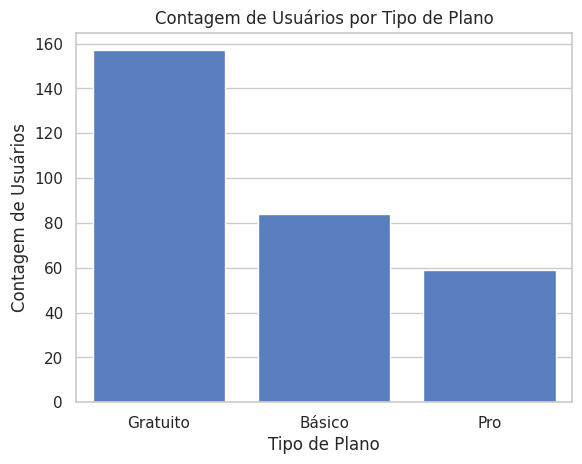

In [4]:
sns.countplot(data=df_sistema, x='plano', order=df_sistema['plano'].value_counts().index)
plt.title('Contagem de Usuários por Tipo de Plano')
plt.xlabel('Tipo de Plano')
plt.ylabel('Contagem de Usuários')
plt.show()


2. Analise a distribuição da variável idade utilizando um histplot. Adicione a curva de densidade **(KDE)** para suavizar a visualização.


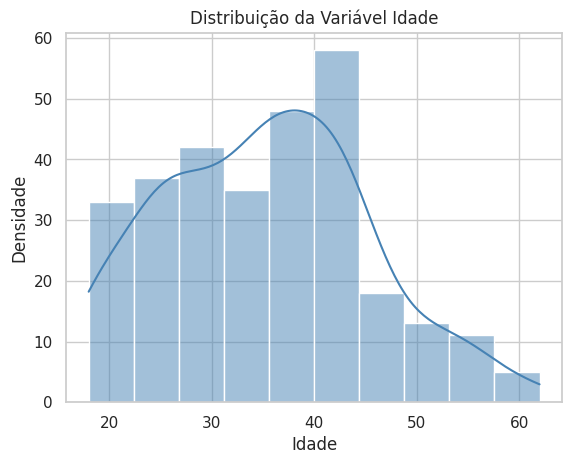

In [6]:
sns.histplot(data=df_sistema, x='idade', bins=10, kde=True, color='steelblue')
plt.title('Distribuição da Variável Idade')
plt.xlabel('Idade')
plt.ylabel('Densidade')
plt.show()

# Parte 2: Relações Categóricas e Numéricas (Intermediário)
3. Construa um boxplot para comparar a distribuição do tempo_uso_horas entre os diferentes tipos de plano.


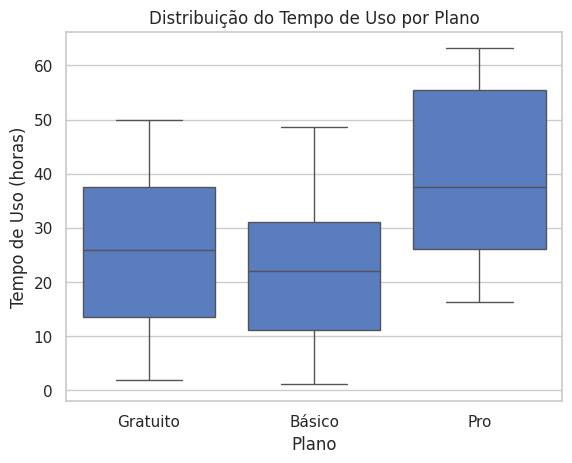

In [8]:
sns.boxplot(data=df_sistema, x='plano', y='tempo_uso_horas')
plt.title('Distribuição do Tempo de Uso por Plano')
plt.xlabel('Plano')
plt.ylabel('Tempo de Uso (horas)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

4. Crie um violinplot cruzando o plano com a satisfacao. Esse gráfico ajudará a entender não apenas a mediana, mas a densidade das notas dadas pelos clientes de cada plano.


/tmp/ipykernel_2092/802441047.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_sistema, x='plano', y='satisfacao', palette='pastel', legend=False)


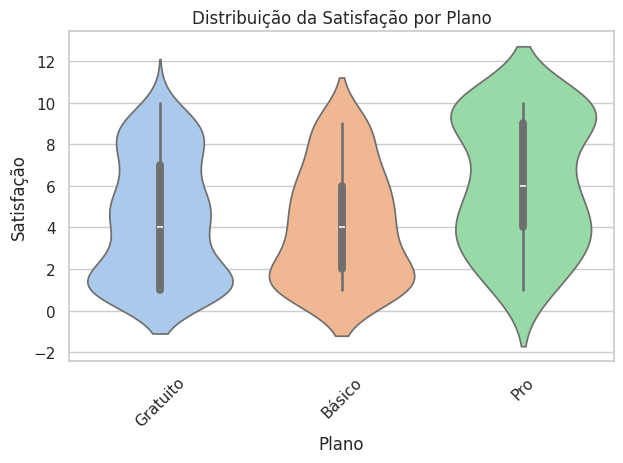

In [17]:
sns.violinplot(data=df_sistema, x='plano', y='satisfacao', palette='pastel', legend=False)
plt.title('Distribuição da Satisfação por Plano')
plt.xlabel('Plano')
plt.ylabel('Satisfação')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Parte 3: Correlações e Análise Multivariada (Avançado)
5. Utilize um scatterplot para investigar a relação entre tempo_uso_horas (eixo X) e satisfacao (eixo Y). Utilize o parâmetro hue para colorir os pontos de acordo com o plano e size para variar o tamanho dos pontos com base nos bugs_reportados.



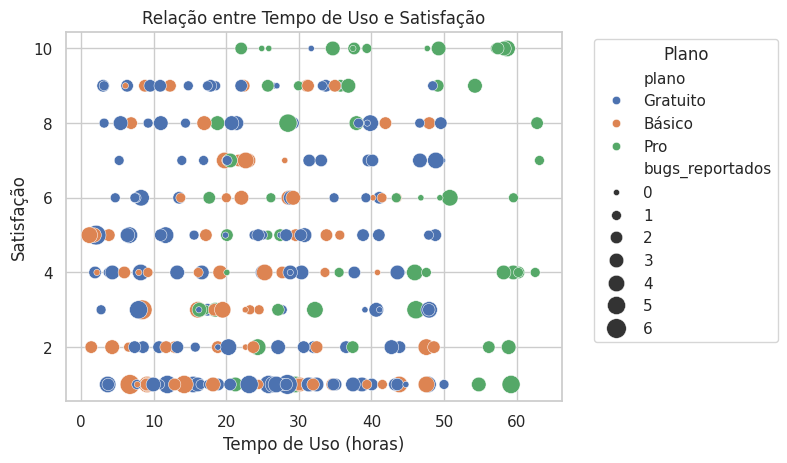

<Figure size 1200x700 with 0 Axes>

In [38]:
sns.scatterplot(data=df_sistema, x='tempo_uso_horas', y='satisfacao', hue='plano', size='bugs_reportados', sizes=(20, 200))
plt.xlabel('Tempo de Uso (horas)')
plt.ylabel('Satisfação')
plt.title('Relação entre Tempo de Uso e Satisfação')
plt.legend(title='Plano', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.figure(figsize=(12, 7))
plt.tight_layout()
plt.show()

6. Calcule a matriz de correlação de Pearson apenas para as variáveis numéricas do DataFrame e visualize-a utilizando um heatmap. Configure a paleta de cores para divergir do centro (ex: 'coolwarm' ou 'vlag') e ative as anotações numéricas (annot=True).


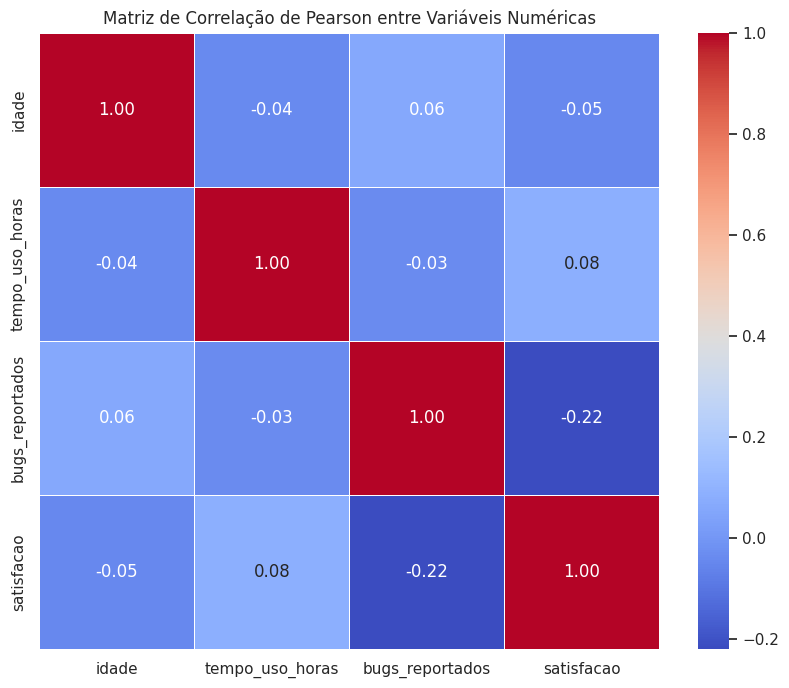

In [40]:
numeric_df = df_sistema.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação de Pearson entre Variáveis Numéricas')
plt.show()

7. (Bônus) Gere um pairplot englobando as variáveis tempo_uso_horas, bugs_reportados e satisfacao, utilizando o plano como hue.

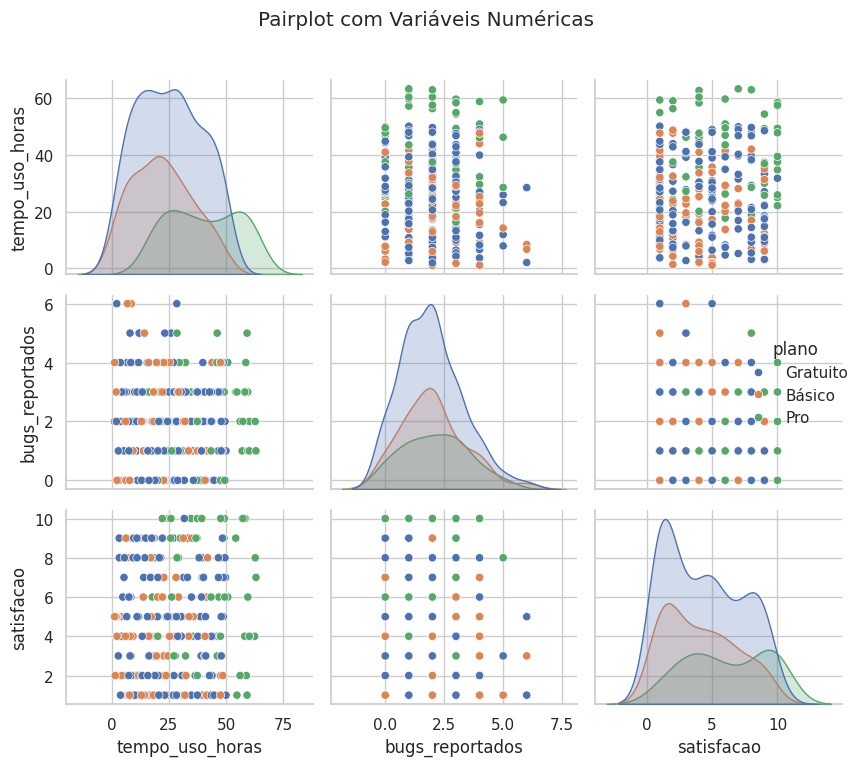

In [42]:
sns.pairplot(data=df_sistema, vars=['tempo_uso_horas', 'bugs_reportados', 'satisfacao'], hue='plano')
plt.suptitle('Pairplot com Variáveis Numéricas', y=1.02)
plt.tight_layout()
plt.show()